# 01 — Exploratory Data Analysis

**Dataset:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — anonymized European cardholder transactions over 48 hours in September 2013.

**Goal of this notebook:** understand the dataset enough to make informed modeling choices in `02_modeling`. Specifically, we want to answer:

1. How imbalanced are the classes? (drives metric choice and resampling strategy)
2. Do `Amount` and `Time` differ between fraud and genuine? (drives feature engineering)
3. Which `V*` features carry the most signal? (sanity check for later feature importance)
4. Which features need scaling? (drives preprocessing pipeline)
5. What split strategy makes sense? (random vs. time-based)

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:.4f}'.format

df = pd.read_csv('../data/raw/creditcard.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 1. Class imbalance

The first thing to check on any classification problem is the class distribution. For fraud detection it's the *defining* characteristic of the problem.

Genuine (0): 284,315  (99.8273%)
Fraud   (1):     492  (0.1727%)
Imbalance ratio: 1 fraud per 578 genuine transactions


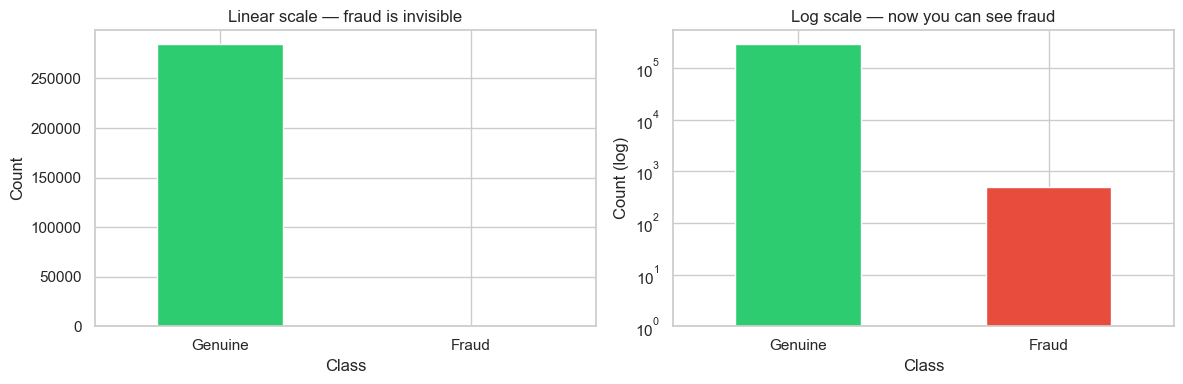

In [2]:
counts = df['Class'].value_counts()
print(f'Genuine (0): {counts[0]:>7,}  ({counts[0]/len(df):.4%})')
print(f'Fraud   (1): {counts[1]:>7,}  ({counts[1]/len(df):.4%})')
print(f'Imbalance ratio: 1 fraud per {counts[0]/counts[1]:.0f} genuine transactions')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
counts.plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Linear scale — fraud is invisible')
ax[0].set_xticklabels(['Genuine', 'Fraud'], rotation=0)
ax[0].set_ylabel('Count')
counts.plot(kind='bar', ax=ax[1], color=['#2ecc71', '#e74c3c'], log=True)
ax[1].set_title('Log scale — now you can see fraud')
ax[1].set_xticklabels(['Genuine', 'Fraud'], rotation=0)
ax[1].set_ylabel('Count (log)')
plt.tight_layout()
plt.show()

**Takeaway:** 0.17% positives. Implications for modeling:
- **Accuracy is useless** — predicting "all genuine" gives 99.83% accuracy. We'll use **PR-AUC, recall, precision, F1**.
- **Stratified splits are mandatory** — a random split could land an unlucky test set with no fraud at all.
- **Class imbalance handling matters** — we'll compare class-weighted loss vs. SMOTE oversampling vs. doing nothing.

## 2. Transaction amount

Does fraud target small or large transactions? `Amount` is one of the only un-anonymized features so it's worth understanding.

In [3]:
df.groupby('Class')['Amount'].describe()[['mean', 'std', '50%', 'max']].round(2)

,mean,std,50%,max
Class,,,,
0,88.2900,250.1100,22.0000,25691.1600
1,122.2100,256.6800,9.2500,2125.8700


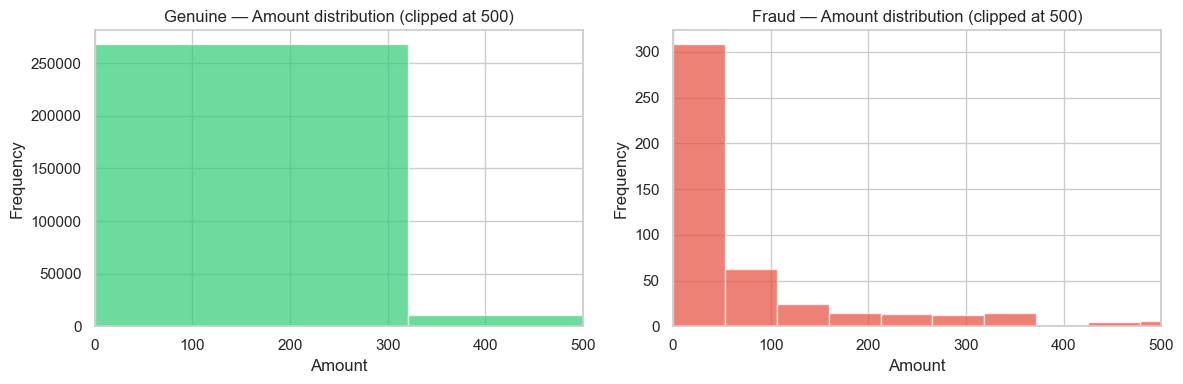

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[df.Class==0]['Amount'].plot(kind='hist', bins=80, ax=ax[0], color='#2ecc71', alpha=0.7)
ax[0].set_title('Genuine — Amount distribution (clipped at 500)')
ax[0].set_xlabel('Amount')
ax[0].set_xlim(0, 500)
df[df.Class==1]['Amount'].plot(kind='hist', bins=40, ax=ax[1], color='#e74c3c', alpha=0.7)
ax[1].set_title('Fraud — Amount distribution (clipped at 500)')
ax[1].set_xlabel('Amount')
ax[1].set_xlim(0, 500)
plt.tight_layout()
plt.show()

**Takeaway:** Fraud has a higher *mean* ($122 vs $88) but a much lower *median* ($9.25 vs $22). Fraudsters often "test" cards with tiny transactions before going big — which is exactly what the median tells us. The genuine distribution has a long tail (max $25,691) while fraud max is $2,125.

## 3. Time patterns

`Time` is *seconds elapsed since the first transaction* in the dataset — not a calendar timestamp. Total span is 48 hours.

In [5]:
print(f'Total time span: {df.Time.max()/3600:.1f} hours = {df.Time.max()/86400:.2f} days')
df['Hour'] = (df.Time // 3600) % 24

fraud_by_hour = df[df.Class==1].groupby('Hour').size()
genuine_by_hour = df[df.Class==0].groupby('Hour').size()
fraud_rate_by_hour = (fraud_by_hour / (fraud_by_hour + genuine_by_hour) * 100).round(3)

print('\nHours with highest fraud RATE (fraud / total transactions in that hour):')
print(fraud_rate_by_hour.sort_values(ascending=False).head(5))

Total time span: 48.0 hours = 2.00 days

Hours with highest fraud RATE (fraud / total transactions in that hour):
Hour
2.0000   1.7130
4.0000   1.0410
3.0000   0.4870
5.0000   0.3680
7.0000   0.3180
dtype: float64


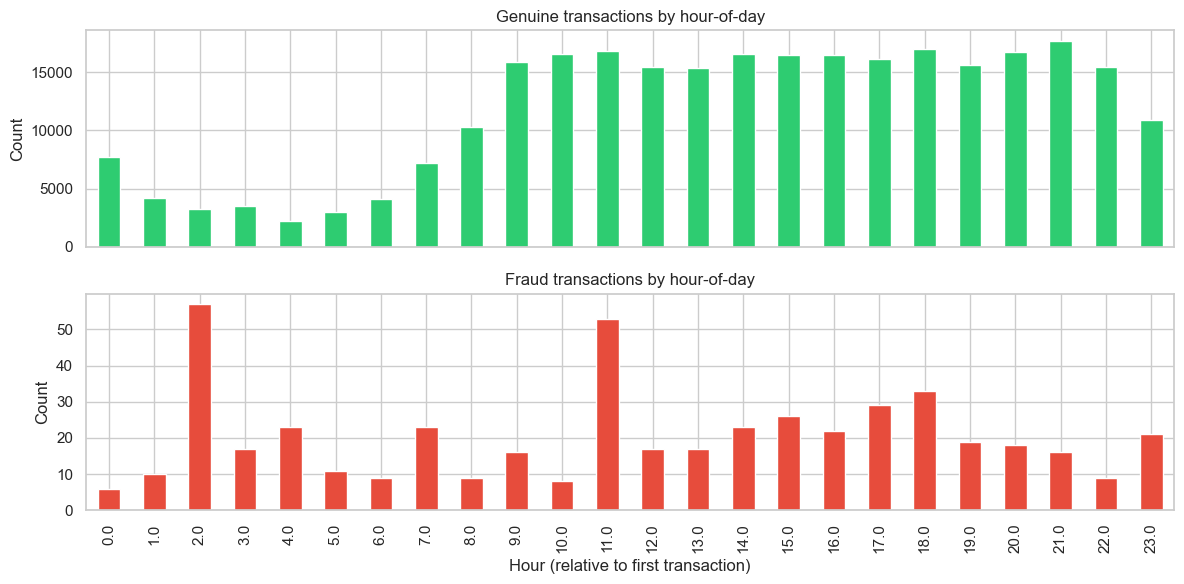

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
genuine_by_hour.plot(kind='bar', ax=ax[0], color='#2ecc71')
ax[0].set_title('Genuine transactions by hour-of-day')
ax[0].set_ylabel('Count')
fraud_by_hour.plot(kind='bar', ax=ax[1], color='#e74c3c')
ax[1].set_title('Fraud transactions by hour-of-day')
ax[1].set_ylabel('Count')
ax[1].set_xlabel('Hour (relative to first transaction)')
plt.tight_layout()
plt.show()

**Takeaway:** Genuine transactions follow a clear day/night cycle (drop overnight). Fraud is roughly *uniform* across hours. The result: the **fraud RATE** spikes at night because the denominator (genuine) collapses while fraud stays steady. Hour-of-day is therefore a useful engineered feature.

We'll drop `Hour` for now (it was just for analysis) and let the model use raw `Time` — engineering the hour feature is something to revisit if we need a boost.

In [7]:
df = df.drop(columns=['Hour'])

## 4. Which features carry signal?

Pearson correlation with the target is a quick first pass. It only catches *linear* relationships, but for binary classification it's a reasonable starting screen.

Top 10 features by |correlation| with Class:
V17   0.3260
V14   0.3030
V12   0.2610
V10   0.2170
V16   0.1970
V3    0.1930
V7    0.1870
V11   0.1550
V4    0.1330
V18   0.1110
Name: Class, dtype: float64


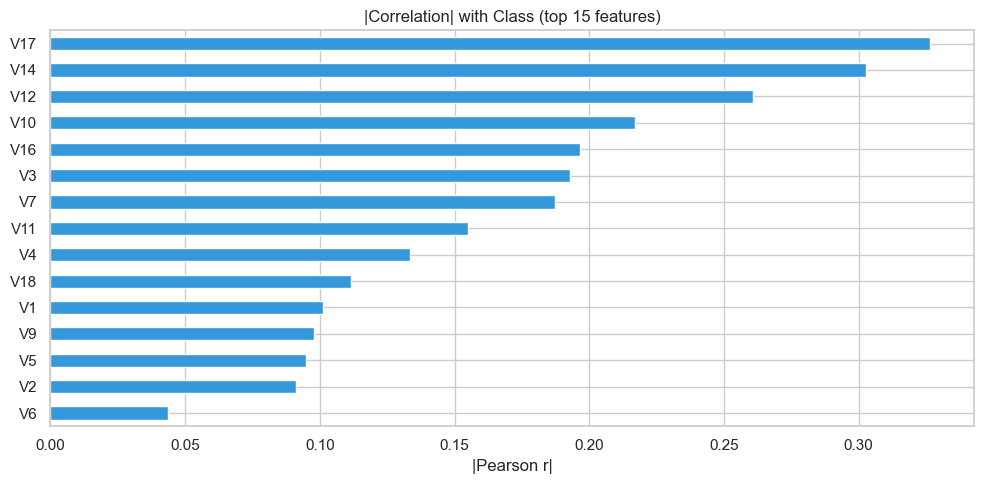

In [8]:
corr = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print('Top 10 features by |correlation| with Class:')
print(corr.head(10).round(3))

fig, ax = plt.subplots(figsize=(10, 5))
corr.head(15).plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('|Correlation| with Class (top 15 features)')
ax.set_xlabel('|Pearson r|')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Takeaway:** A handful of V-features (V17, V14, V12, V10) carry the most linear signal. We'll compare these against XGBoost's gain-based feature importance later — they should largely agree.

## 5. Feature scales — do we need to scale?

Logistic regression and distance-based models care about feature scale. Tree-based models (XGBoost, LightGBM) don't.

In [9]:
df[['Time', 'Amount', 'V1', 'V14', 'V28']].describe().round(2).T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
Time,94813.8600,47488.1500,0.0000,172792.0000
Amount,88.3500,250.1200,0.0000,25691.1600
V1,0.0000,1.9600,-56.4100,2.4500
V14,0.0000,0.9600,-19.2100,10.5300
V28,-0.0000,0.3300,-15.4300,33.8500


**Takeaway:** `Time` ranges 0 to 172,792. `Amount` ranges 0 to 25,691. The V-features are already on roughly unit scale (the dataset authors PCA'd them). For the logistic regression baseline we'll wrap a `StandardScaler` around `Time` and `Amount` only. For XGBoost we won't bother.

## 6. Decisions for `02_modeling`

| Decision | Choice | Reason |
|---|---|---|
| Primary metric | **PR-AUC** | Right metric for highly imbalanced binary classification |
| Secondary metrics | Recall, Precision, F1, ROC-AUC | Recall = how much fraud we catch; Precision = how often our alerts are real |
| Split strategy | **Stratified train/val/test (60/20/20)** | Guarantees fraud appears in every split; the dataset is only 48 hours, so a time-based split would over-fit one half-day's behavior |
| Scaling | `StandardScaler` on `Time` & `Amount` only | V1–V28 already PCA-scaled |
| Imbalance handling | Compare 3 strategies: none, `class_weight`, SMOTE | We'll let the data tell us |
| Models | Logistic regression (baseline) → XGBoost (contender) | Always start with a strong baseline |